an exploration of team shooting performance in the NWSL

In [68]:
import pandas as pd
import numpy as np
import pymc as pm
import pymc_bart as pmb
import arviz as az

RANDOM_SEED = 139

In [69]:
df = pd.read_csv("shooting.csv")

#remove nas
df = df.dropna().copy()
df['season'] = pd.to_numeric(df["season"], errors= 'coerce')
df['gf'] = pd.to_numeric(df['gf'], errors= 'coerce')

# Select all object and category columns
#cat_cols = df.select_dtypes(['object', 'category']).columns
cat_cols = ['team', 'round', 'day', 'venue', 'result', 'opp', 'date', 'time']
# Apply cat.codes to all of them
df[cat_cols] = df[cat_cols].apply(lambda x: x.astype('category').cat.codes)

#make everything else numeric
df[df.columns.difference(cat_cols)] = df[df.columns.difference(cat_cols)].apply(pd.to_numeric, errors='coerce')



In [70]:
# how many seasons are we working with
df['season'].unique()

array([2025, 2024, 2023, 2021, 2019])

In [114]:
# Train on everything before 2025, test on 2025
train_df = df[df['season'] < 2025].copy()
infer_df = df[df['season'] == 2025].copy()

# Force 'gf' to numeric and drop any games missing 'gf' in the training set
train_df['gf'] = pd.to_numeric(train_df['gf'], errors='coerce')
train_df = train_df.dropna(subset=['gf'])
train_target = train_df["gf"].astype(int)

# CRITICAL FIX: Only select features known BEFORE the match starts!
# If you include match stats like 'sh' or 'xg', 2025 will be NaNs and the model will crash.
pre_match_features = ['team', 'opp', 'venue', 'round', 'day']

train_features = train_df[pre_match_features]
infer_features = infer_df[pre_match_features]

# Just to be 100% safe, fill any accidental blank categories with -1
train_features = train_features.fillna(-1)
infer_features = infer_features.fillna(-1)

define bart. use a poisson distribution for goal scored because that is the most commonly used one for soccer goals. 

In [115]:
with pm.Model() as nwsl_model:
    X_data = pm.Data("X_data", train_features)
    y_data = pm.Data("y_data", train_target)
    #start by defining BART prior
    mu_bart = pmb.BART("mu_bart", X_data, y_data, m=50)
    lam = pm.math.exp(mu_bart)
    y_obs = pm.Poisson('y_obs', mu = lam, observed = y_data)
    trace_nwsl = pm.sample(random_seed= RANDOM_SEED)

Multiprocess sampling (4 chains in 4 jobs)
PGBART: [mu_bart]
                                                 
  Progress   Draw   Speed   Elapsed   Remaining  
 ─────────────────────────────────────────────── 
                                                                                        
  Progress                                   Draw   Speed          Elapsed   Remaining  
 ────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   0      0.00 draws/s   0:00:00   -:--:--    
                                                                                        
  Progress                                   Draw   Speed          Elapsed   Remaining  
 ────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   0      0.00 draws/s   0:00:00   -:--:--    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   0      0.00 draws/s   0:00:00   

check some plots and convergence of the MCMC chains

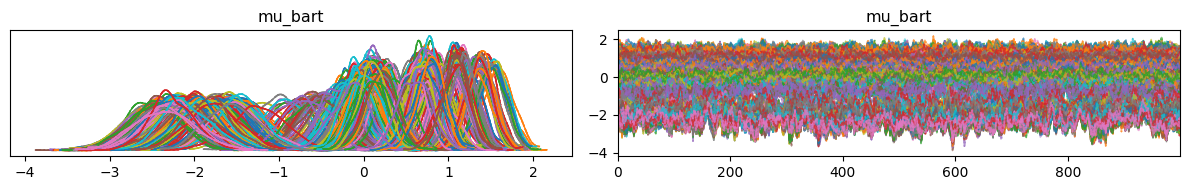

In [85]:
import arviz_plots as azp
import matplotlib.pyplot as plt

az.plot_trace(trace_nwsl)
plt.tight_layout()
plt.show()

then look at summary statistics. Want an r hat close to 1 or 1.01 for most of these

In [86]:
# Generate a statistical summary of the trace
summary_df = az.summary(trace_nwsl)

# Display the key convergence columns
print(summary_df[['mean', 'sd', 'hdi_3%', 'hdi_97%', 'r_hat', 'ess_bulk']])

                mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk
mu_bart[0]    -1.923  0.324  -2.564   -1.332   1.01     530.0
mu_bart[1]    -0.621  0.262  -1.113   -0.120   1.00     574.0
mu_bart[2]     0.680  0.160   0.364    0.962   1.00     563.0
mu_bart[3]    -2.173  0.288  -2.726   -1.649   1.01     469.0
mu_bart[4]     0.763  0.183   0.410    1.105   1.01     621.0
...              ...    ...     ...      ...    ...       ...
mu_bart[1062]  0.140  0.204  -0.250    0.498   1.00     536.0
mu_bart[1063] -2.266  0.266  -2.740   -1.735   1.00     716.0
mu_bart[1064]  0.606  0.193   0.258    0.968   1.01     627.0
mu_bart[1065]  1.087  0.168   0.787    1.421   1.00     582.0
mu_bart[1066] -2.350  0.361  -3.045   -1.722   1.00     385.0

[1067 rows x 6 columns]


looking for uniform chains. spikes to right or left indicate poor convergence and that that chain got caught up in parameter space.

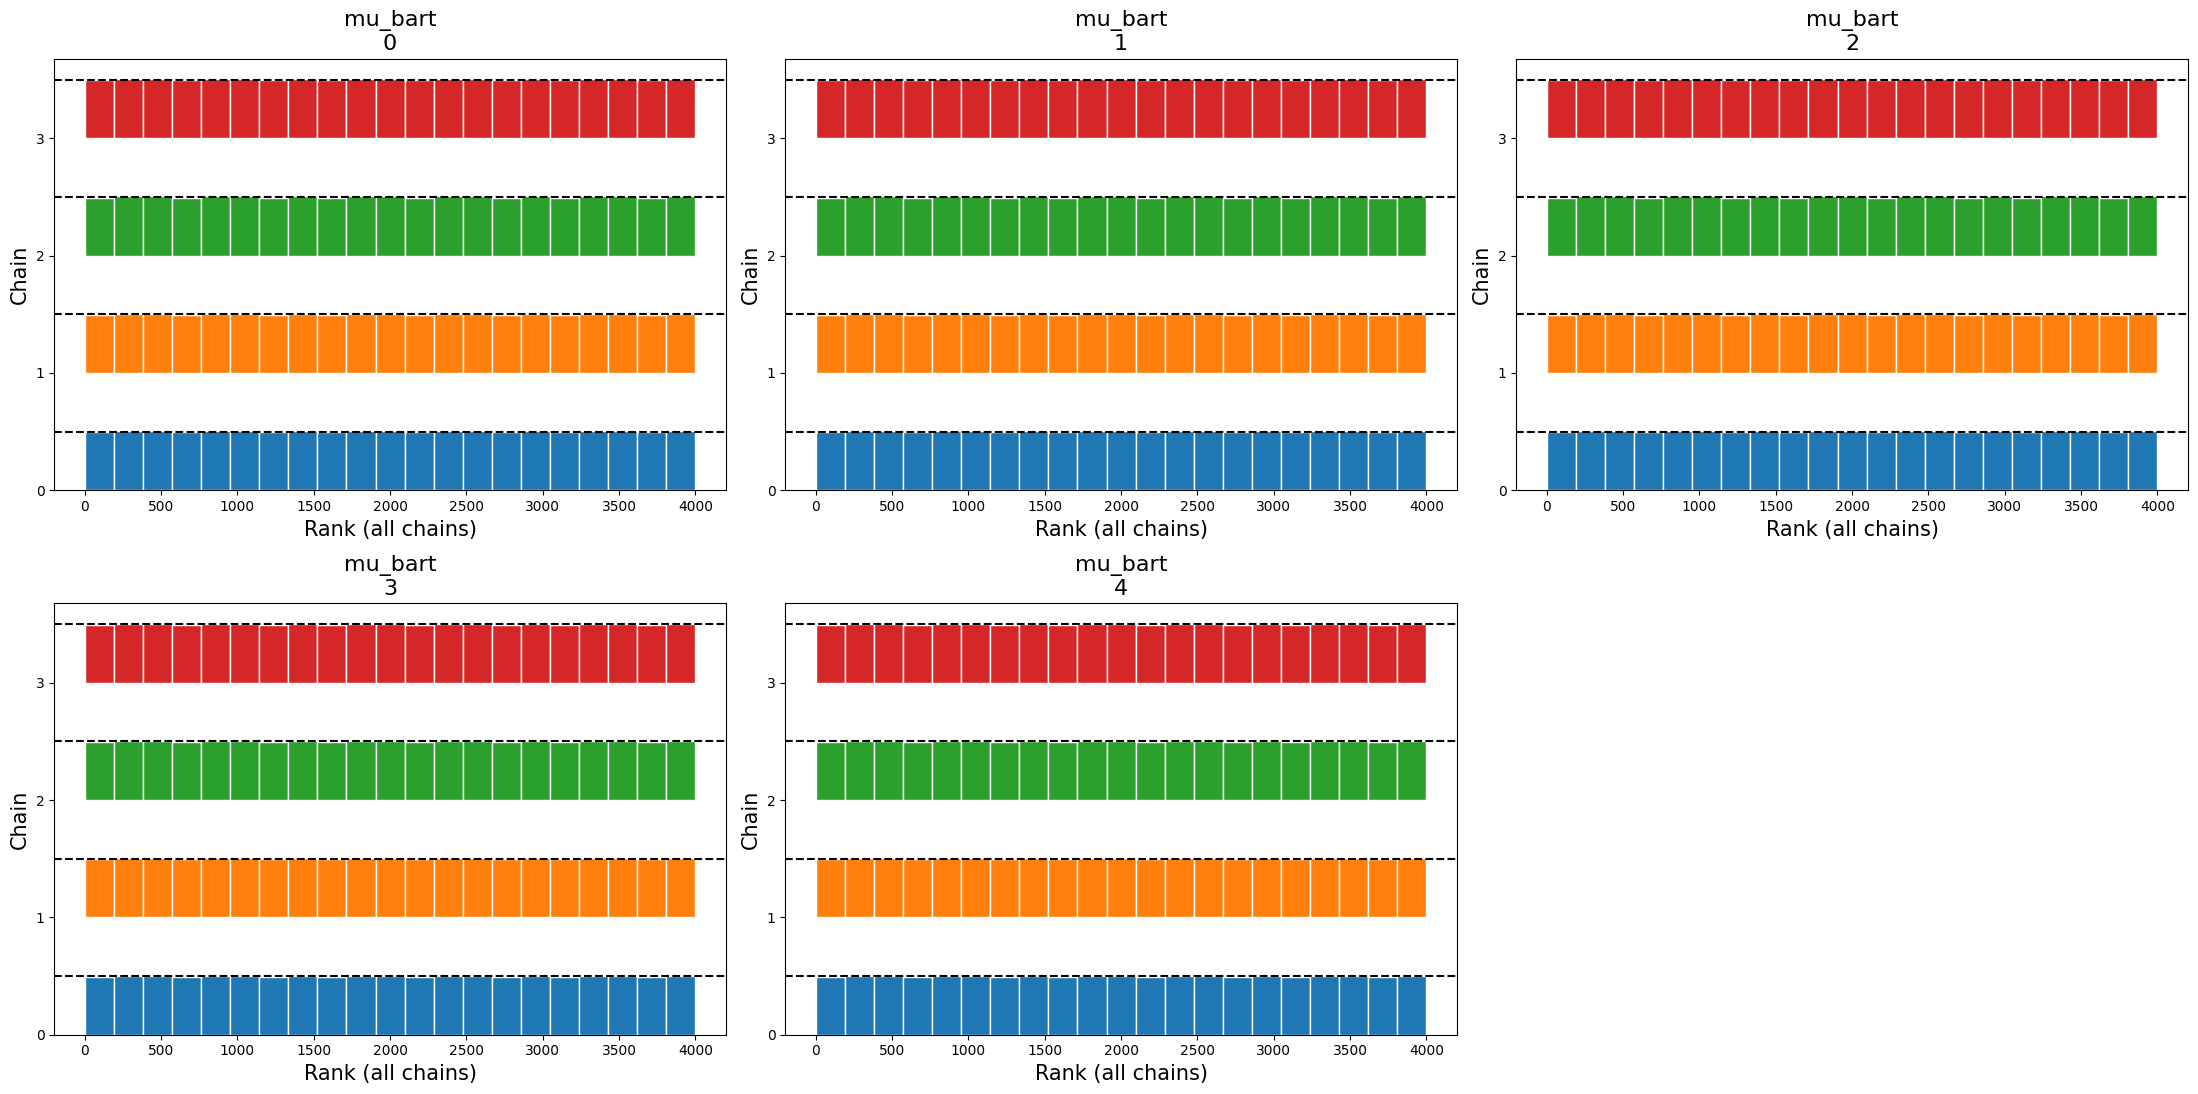

In [87]:
# Generate a rank plot
az.plot_rank(trace_nwsl, 
              coords = {"mu_bart_dim_0": [0, 1, 2, 3, 4]})
plt.tight_layout()
plt.show()

array([<Axes: xlabel='season'>, <Axes: xlabel='team'>, <Axes: xlabel='round'>, <Axes: xlabel='day'>,
       <Axes: xlabel='venue'>, <Axes: xlabel='opp'>, <Axes: xlabel='tm_std_Gls'>, <Axes: xlabel='tm_std_Sh'>,
       <Axes: xlabel='tm_std_SoT'>, <Axes: xlabel='tm_std_Sot%'>, <Axes: xlabel='tm_std_G_Sh'>,
       <Axes: xlabel='tm_std_G_SoT'>, <Axes: xlabel='tm_std_Dist'>, <Axes: xlabel='tm_std_FK'>,
       <Axes: xlabel='tm_std_PK'>, <Axes: xlabel='tm_std_PKatt'>, <Axes: xlabel='tm_exp_xG'>,
       <Axes: xlabel='tm_exp_npxG'>, <Axes: xlabel='tm_exp_npxG_Sh'>, <Axes: xlabel='tm_exp_G_xG'>,
       <Axes: xlabel='tm_exp_np_G_xG'>, <Axes: xlabel='opp_std_Gls'>, <Axes: xlabel='opp_std_Sh'>,
       <Axes: xlabel='opp_std_SoT'>, <Axes: xlabel='opp_std_Sot%'>, <Axes: xlabel='opp_std_G_Sh'>,
       <Axes: xlabel='opp_std_G_SoT'>, <Axes: xlabel='opp_std_Dist'>, <Axes: xlabel='opp_std_FK'>,
       <Axes: xlabel='opp_std_PK'>, <Axes: xlabel='opp_std_PKatt'>, <Axes: xlabel='opp_exp_xG'>,
       <A

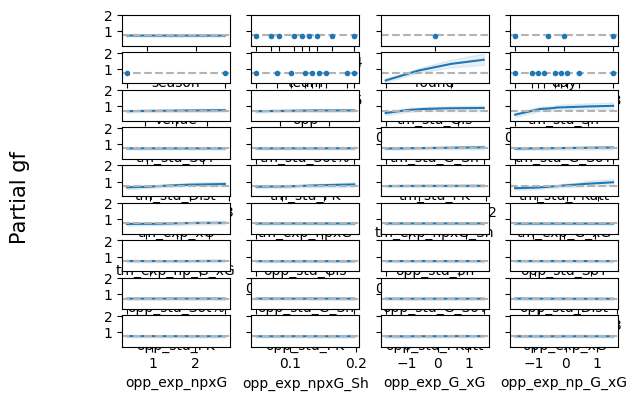

In [88]:
pmb.plot_pdp(mu_bart, 
X=features, 
Y=target, 
grid=(10, 4), 
func=np.exp,
var_discrete=[1,2,3,4,5,7],
smooth = False
)

then lets check out feature importance

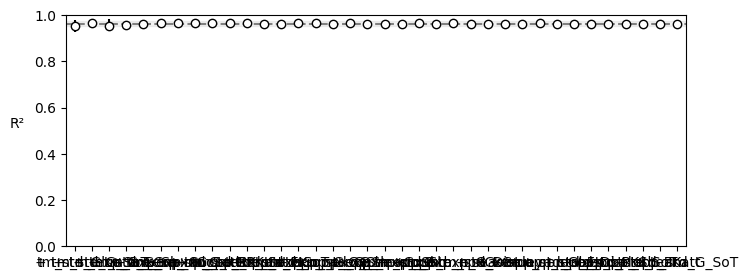

In [89]:
vi_results = pmb.compute_variable_importance(trace_nwsl, mu_bart, features)
pmb.plot_variable_importance(vi_results);

In [118]:
with nwsl_model:
    # Dummy target tricks PyMC into resizing the output predictions
    dummy_target = np.zeros(len(infer_features), dtype=int)
    
    pm.set_data({
        "X_data": infer_features,
        "y_data": dummy_target
    })
    
    # This will no longer crash because there are no NaNs in the features!
    predictions_2025 = pm.sample_posterior_predictive(
        trace=trace_nwsl, 
        random_seed=RANDOM_SEED
    )

# Extract and view predictions
gf_2025_expected = predictions_2025.posterior_predictive["y_obs"].mean(dim=["chain", "draw"])
infer_df = infer_df.copy()
infer_df["predicted_gf"] = gf_2025_expected.values

print(infer_df[['season', 'team', 'opp', 'predicted_gf']].head(15))

Sampling: [mu_bart, y_obs]
Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:11 0:00:01 / 0:00:1100:01 / 0:00:11


    season  team  opp  predicted_gf
0     2025     0   16       1.35000
1     2025     0   15       1.21625
2     2025     0   11       1.54425
3     2025     0    5       1.26125
5     2025     0    9       1.22450
6     2025     0   14       1.23950
7     2025     0   12       1.40850
8     2025     0    1       1.35150
9     2025     0    8       1.45350
10    2025     0    2       1.45475
11    2025     0    3       1.38300
12    2025     0    4       1.17575
13    2025     1   12       1.36900
14    2025     1    8       1.45450
15    2025     1   14       1.22275


In [122]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure the actual 'gf' is numeric
infer_df['actual_gf'] = pd.to_numeric(infer_df['gf'], errors='coerce')

# Drop any rows where the actual game hasn't happened yet or is missing
eval_df = infer_df.dropna(subset=['actual_gf', 'predicted_gf']).copy()

# Calculate Error Metrics
eval_df['error'] = eval_df['predicted_gf'] - eval_df['actual_gf']
eval_df['abs_error'] = np.abs(eval_df['error'])
eval_df['sq_error'] = eval_df['error'] ** 2

mae = eval_df['abs_error'].mean()
rmse = np.sqrt(eval_df['sq_error'].mean())

print(f"--- 2025 Match-by-Match Prediction Accuracy ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} goals per game")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} goals per game\n")

# 1. Read the raw CSV again to grab the original string names
raw_df = pd.read_csv("shooting.csv").dropna().copy()

# 2. Extract the categorical mapping
# pandas assigns codes alphabetically, so we can just enumerate the categories
team_categories = raw_df['team'].astype('category').cat.categories
team_mapping = {code: name for code, name in enumerate(team_categories)}

# Do the same for the opponent column just in case it has slightly different categories
opp_categories = raw_df['opp'].astype('category').cat.categories
opp_mapping = {code: name for code, name in enumerate(opp_categories)}

# 3. Map the integer codes back to strings in your evaluation dataframe
eval_df['team'] = eval_df['team'].map(team_mapping)
eval_df['opp'] = eval_df['opp'].map(opp_mapping)

# 4. Print the corrected results!
print("Matches where actual goals differed most from predicted:")
print(eval_df[['team', 'opp', 'actual_gf', 'predicted_gf', 'error', 'abs_error']].sort_values(by='abs_error', ascending=False).head(5))


--- 2025 Match-by-Match Prediction Accuracy ---
Mean Absolute Error (MAE): 0.95 goals per game
Root Mean Squared Error (RMSE): 1.18 goals per game

Matches where actual goals differed most from predicted:
                   team            opp  actual_gf  predicted_gf    error  abs_error
91        Orlando Pride  Chicago Stars        6.0       1.51600 -4.48400    4.48400
139      San Diego Wave        Courage        5.0       1.38650 -3.61350    3.61350
155    Seattle Reign FC         Royals        4.0       1.16325 -2.83675    2.83675
113  Portland Thorns FC           Dash        4.0       1.17125 -2.82875    2.82875
134      San Diego Wave     Louisville        4.0       1.19100 -2.80900    2.80900


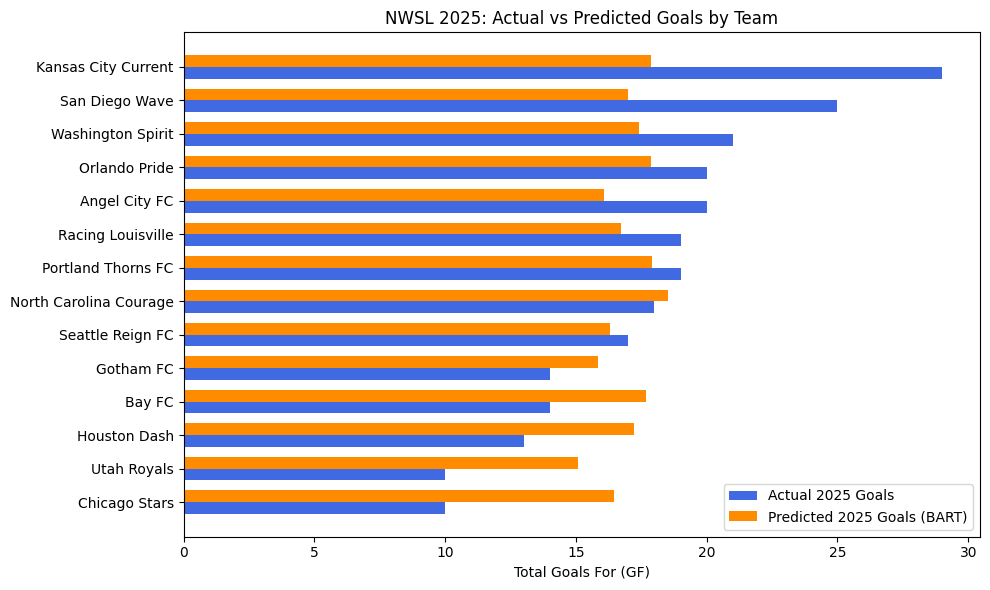


--- 2025 Season Totals ---
                  team  Total_Actual_GF  Total_Predicted_GF
         Chicago Stars             10.0            16.45075
           Utah Royals             10.0            15.07650
          Houston Dash             13.0            17.22800
                Bay FC             14.0            17.68500
             Gotham FC             14.0            15.84625
      Seattle Reign FC             17.0            16.30600
North Carolina Courage             18.0            18.50425
    Portland Thorns FC             19.0            17.89900
     Racing Louisville             19.0            16.72525
         Angel City FC             20.0            16.06275
         Orlando Pride             20.0            17.87200
     Washington Spirit             21.0            17.40650
        San Diego Wave             25.0            16.99150
   Kansas City Current             29.0            17.85525


In [125]:
# Aggregate total actual goals and total predicted goals per team

team_totals = eval_df.groupby('team').agg(
    Total_Actual_GF=('actual_gf', 'sum'),
    Total_Predicted_GF=('predicted_gf', 'sum')
).reset_index()

# Sort by Actual Goals for a cleaner plot
team_totals = team_totals.sort_values('Total_Actual_GF', ascending=True)

#team_totals['team'] = team_totals['team'].map(team_mapping)
# ---------------------------------------------------------
# Plot: Actual vs Predicted 2025 Goals by Team
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# We use the team codes for the Y-axis positions
y_positions = np.arange(len(team_totals))
bar_height = 0.35

# Plot actual and predicted bars side-by-side
ax.barh(y_positions - bar_height/2, team_totals['Total_Actual_GF'], 
        height=bar_height, label='Actual 2025 Goals', color='royalblue')
ax.barh(y_positions + bar_height/2, team_totals['Total_Predicted_GF'], 
        height=bar_height, label='Predicted 2025 Goals (BART)', color='darkorange')

# Formatting the plot
ax.set_yticks(y_positions)
ax.set_yticklabels(team_totals['team']) # If you mapped team names back, they will show here!
ax.set_xlabel('Total Goals For (GF)')
ax.set_title('NWSL 2025: Actual vs Predicted Goals by Team')
ax.legend()

plt.tight_layout()
plt.show()

# Print the aggregated dataframe
print("\n--- 2025 Season Totals ---")
print(team_totals.to_string(index=False))